In [445]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow

In [446]:
df_raw = pd.read_csv("Sample-Superstore2019.csv",parse_dates=["Order Date","Ship Date"])
df=df_raw.copy()

In [447]:
df["Postal Code"]=df["Postal Code"].astype(str)

In [448]:
df = df.iloc[:,2 :]

In [449]:
class Cleaning:

    def __init__(self, df):
        self.df = df
        print(f"Shape is: {self.df.shape}")
        print("*"*30)
        
    def head(self, n=10):
        return self.df.head(n)
    # **************************************************
    def check_NaN(self):
        return self.df.isna().sum().sum() > 0

    # **************************************************
    def Fill_NaN(self, value):
        if self.check_NaN():
            self.df.fillna(value, inplace=True)
        else:
            print("There are NO NULL values")
        print(f"The number of NaN values:\n{self.df.isna().sum()}")


    # **************************************************
    def Check_Duplicates(self):
        return self.df.duplicated().sum() != 0

    # **************************************************
    def Remove_Duplicates(self):
        if self.Check_Duplicates():
            self.df.drop_duplicates(inplace=True)
        else:
            print("There are NO duplicates")

    # **************************************************
    def info(self):
        return self.df.info(memory_usage="deep")

    # **************************************************
    def Change_Type(self, cols=None, Type=object):

        if cols is None:
            cols = []

        try:
            for col in cols:
                self.df[col] = self.df[col].astype(Type)

        except Exception as e:
            print(f"Error: {e}")
    #*******************************************************
    def Calc_Outlier(self, cols=None):

        if cols is None:
            cols = self.df.select_dtypes(include="number").columns.tolist()

        for col in cols:
            q1 = self.df[col].quantile(0.25)
            q3 = self.df[col].quantile(0.75)
            iqr = q3 - q1

            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

            outliers = self.df[
                (self.df[col] < lower_bound) |
                (self.df[col] > upper_bound)
            ]

            print(f"\n{col}")
            print(f"Outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
            print(f"Number of outliers: {len(outliers)}")
    #*******************************************************        
    def Save_Cleaning(self, filename="cleaned_data.parquet"):
        self.df.to_parquet(filename, engine="pyarrow", index=False)
        print(f"Data saved successfully to {filename}")
    #*******************************************************
    def value_count(self, cols=None):

        if cols is None:
            cols = self.df.select_dtypes(
                include=["object", "category"]
            ).columns.tolist()

        for col in cols:
            print()
            print(self.df[col].value_counts())  
    #*******************************************************
    def show_Outlier(self, cols=None):

        if cols is None:
            cols = self.df.select_dtypes(include="number").columns.tolist()

        n = len(cols)
        rows = (n + 1) // 2

        fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows))

        axes = axes.flatten()

        for ax, col in zip(axes, cols):
            ax.boxplot(self.df[col], vert=False)
            ax.set_title(f"{col} Distribution")
            ax.set_xlabel(col)

        for ax in axes[n:]:
            ax.remove()

        plt.tight_layout()
        plt.show()

In [450]:
clean=Cleaning(df=df)


Shape is: (9994, 20)
******************************


In [451]:
clean.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [452]:
clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        9994 non-null   str           
 1   Order Date      9994 non-null   datetime64[us]
 2   Ship Date       9994 non-null   datetime64[us]
 3   Ship Mode       9994 non-null   str           
 4   Customer ID     9994 non-null   str           
 5   Customer Name   9994 non-null   str           
 6   Segment         9994 non-null   str           
 7   Country/Region  9994 non-null   str           
 8   City            9994 non-null   str           
 9   State           9994 non-null   str           
 10  Postal Code     9983 non-null   str           
 11  Region          9994 non-null   str           
 12  Product ID      9994 non-null   str           
 13  Category        9994 non-null   str           
 14  Sub-Category    9994 non-null   str           
 15  Product Name   

In [453]:
clean.Fill_NaN("05401")

The number of NaN values:
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


In [454]:
clean.Check_Duplicates()

np.True_

In [455]:
clean.Remove_Duplicates()

In [456]:
clean.Change_Type(["Segment", "Region", "Ship Mode", "Category","State","Sub-Category"],Type="category")

In [457]:
clean.info()

<class 'pandas.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        9993 non-null   str           
 1   Order Date      9993 non-null   datetime64[us]
 2   Ship Date       9993 non-null   datetime64[us]
 3   Ship Mode       9993 non-null   category      
 4   Customer ID     9993 non-null   str           
 5   Customer Name   9993 non-null   str           
 6   Segment         9993 non-null   category      
 7   Country/Region  9993 non-null   str           
 8   City            9993 non-null   str           
 9   State           9993 non-null   category      
 10  Postal Code     9993 non-null   str           
 11  Region          9993 non-null   category      
 12  Product ID      9993 non-null   str           
 13  Category        9993 non-null   category      
 14  Sub-Category    9993 non-null   category      
 15  Product Name    9993

In [458]:
clean.value_count(cols=["Country/Region","City"])


Country/Region
United States    9993
Name: count, dtype: int64

City
New York City        915
Los Angeles          747
Philadelphia         537
San Francisco        510
Seattle              428
                    ... 
Aberdeen               1
Hagerstown             1
Arlington Heights      1
San Luis Obispo        1
Springdale             1
Name: count, Length: 531, dtype: int64


In [459]:
clean.Calc_Outlier()


Sales
Outlier bounds: [-271.71, 498.93]
Number of outliers: 1167

Quantity
Outlier bounds: [-2.50, 9.50]
Number of outliers: 170

Discount
Outlier bounds: [-0.30, 0.50]
Number of outliers: 856

Profit
Outlier bounds: [-39.72, 70.81]
Number of outliers: 1881


C:\Users\Hamza\AppData\Local\Temp\ipykernel_5264\555193198.py:101: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(self.df[col], vert=False)
C:\Users\Hamza\AppData\Local\Temp\ipykernel_5264\555193198.py:101: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(self.df[col], vert=False)
C:\Users\Hamza\AppData\Local\Temp\ipykernel_5264\555193198.py:101: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(self.df[col], vert=False)
C:\Users\Hamza\AppData\Local\Temp\ipykernel_5264\555193198.py:101: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizonta

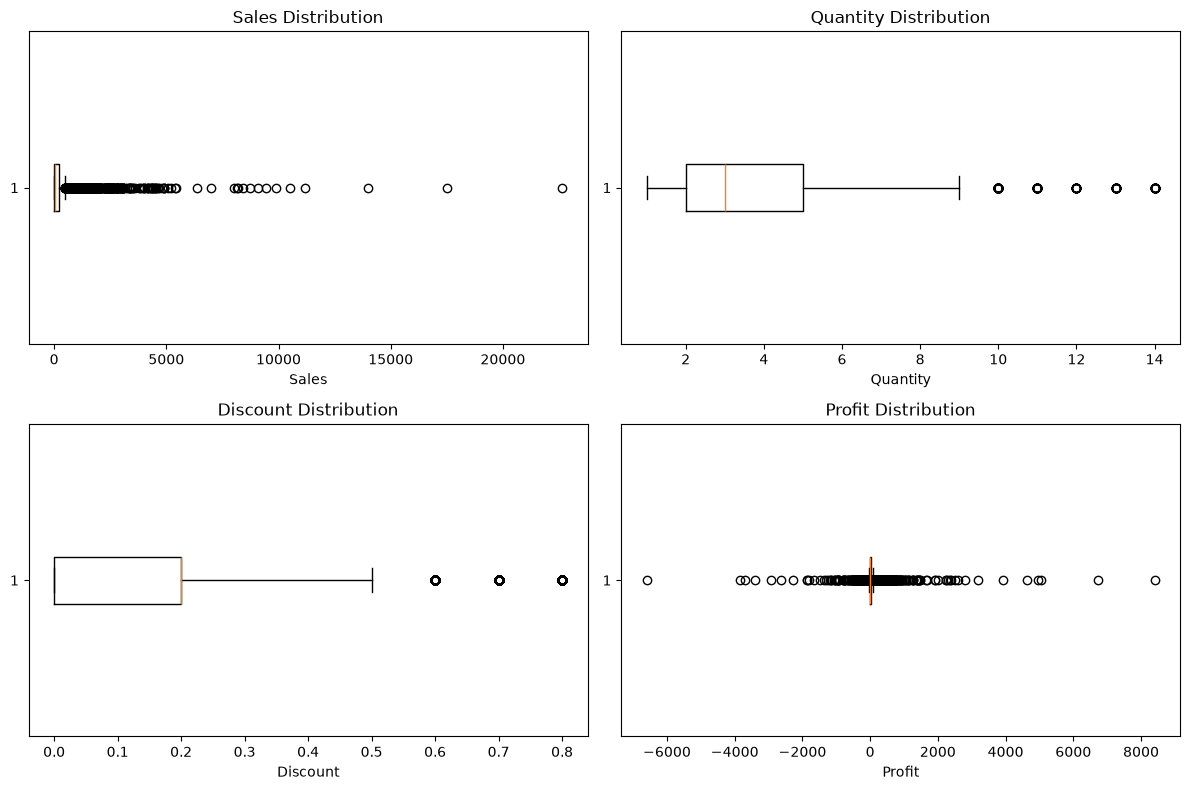

In [460]:
clean.show_Outlier()

In [461]:
clean.Save_Cleaning()

Data saved successfully to cleaned_data.parquet
